---
title: "Predict Restaurant Ratings with TabPFN 3.5"
description: "Compare TabPFN 3.5 and TabPFN 3 with and without thinking, plus default and tuned XGBoost with TF-IDF on Zomato text and tabular data."
icon: utensils
cookbookTags:
  - benchmark
  - regression
  - text
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
featured: true
---

Restaurant listings combine structured fields, such as votes and location, with free text, such as customer reviews. In this cookbook, we predict Zomato ratings with TabPFN 3.5 and TabPFN 3, each with and without thinking mode, and default and tuned XGBoost.

We use all 41,665 rated listings, with the same source columns and data splits for every model. TabPFN accepts the text directly. For XGBoost, we turn text into TF-IDF features and tune hyperparameters for five minutes on a separate validation set.


## Setup

TabPFN runs through the API. In Colab, add `TABPFN_TOKEN` to your secrets using the key icon. Locally, set the `TABPFN_TOKEN` environment variable or use the client’s existing authentication.


In [1]:
%pip install -q tabpfn-client "xgboost==2.1.4" "optuna==4.9.0" "scikit-learn==1.6.1" "pandas==2.3.3" "matplotlib==3.10.1"


Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import os
import time
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

if not os.environ.get("TABPFN_TOKEN"):
    try:
        from google.colab import userdata

        token = userdata.get("TABPFN_TOKEN")
        if token:
            os.environ["TABPFN_TOKEN"] = token
    except ImportError:
        pass  # Outside Colab, use the client's local authentication.

from tabpfn_client import TabPFNRegressor
from tabpfn_client.api_models import ModelVersion

SEED = 42
DEVICE = "cpu"


## Load and split the listings

The [curated MulTaBench dataset](https://www.kaggle.com/datasets/chico89/multabench-zomato-restaurants) contains 41,665 rated listings from the [original Zomato dataset](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants). Ratings are numeric and URLs have already been removed.

Split the dataset into 80% training, 10% validation, and 10% testing. XGBoost uses validation RMSE to select hyperparameters and tree count. Once tuning finishes, both XGBoost and TabPFN fit on all 37,498 training plus validation rows.

This is a random **listing-level** split: restaurants can recur across splits, and `reviews_list` contains individual review scores. The task is to estimate existing listings' aggregate ratings; it does not measure performance on unseen restaurants or future ratings.


In [3]:
data_dir = Path("data/zomato")
data_dir.mkdir(parents=True, exist_ok=True)
if not (data_dir / "data.csv").exists():
    urlretrieve(
        "https://www.kaggle.com/api/v1/datasets/download/chico89/"
        "multabench-zomato-restaurants?datasetVersionNumber=1",
        data_dir / "dataset.zip",
    )
    with ZipFile(data_dir / "dataset.zip") as archive:
        (data_dir / "data.csv").write_bytes(archive.read("data.csv"))

df = pd.read_csv(data_dir / "data.csv")
assert len(df) == 41_665 and df["rate"].between(0, 5).all()
cost_column = "approx cost(for two people)"
df[cost_column] = pd.to_numeric(
    df[cost_column].astype(str).str.replace(",", "", regex=False), errors="coerce"
)

train_valid, test = train_test_split(df, test_size=0.1, random_state=SEED)
train, valid = train_test_split(train_valid, test_size=1 / 9, random_state=SEED)

X_train, y_train = train.drop(columns="rate"), train["rate"].to_numpy()
X_valid, y_valid = valid.drop(columns="rate"), valid["rate"].to_numpy()
X_train_valid = train_valid.drop(columns="rate")
y_train_valid = train_valid["rate"].to_numpy()
X_test, y_test = test.drop(columns="rate"), test["rate"].to_numpy()
print(f"Train: {len(train):,}; validation: {len(valid):,}; test: {len(test):,}")
print(f"Final training set for every model: {len(train_valid):,} rows")


Train: 33,331; validation: 4,167; test: 4,167
Final training set for every model: 37,498 rows


### Sample listings and text

Inspect a few training listings, then read one complete set of their source text fields.

In [4]:
with pd.option_context("display.max_columns", None, "display.max_colwidth", 70):
    display(train.head(3))

for column in ["reviews_list", "menu_item", "dish_liked"]:
    print(f"{column}:\n{train.iloc[0][column]}\n")

,address,name,online_order,book_table,votes,phone,location,rest_type,dish_liked,cuisines,approx cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),rate
36208,"5, 6/1, Opposite, Indicash ATM, Sri Ram Temple Road, Ejipura, Bang...",Assi Tussi Lassi,Yes,No,27,+91 9066331614,Ejipura,Beverage Shop,NaN,"Beverages, Fast Food, Ice Cream",200.0,"[('Rated 5.0', 'RATED\n Had been there after a tiring day at work...","['Sweet Lassi', 'Banana Lassi', 'Mango Lassi', 'Strawberry Lassi',...",Delivery,Old Airport Road,3.7
7166,"Shop 26, Opposite Gopalan Innovation Mall, 2nd Stage, Bannerghatta...",Udupi Thaja Thindi,Yes,No,42,080 26684932\r\r\n+91 9448180376,BTM,Quick Bites,"Masala Dosa, Vada, Filter Coffee","North Indian, South Indian, Chinese, Fast Food",250.0,"[('Rated 3.0', ""RATED\n Ate butter roti and paneer butter masala....","['2 Idli with 1 Vada', 'Rice Bath', 'Masala Dosa', 'Ghee Masala Do...",Delivery,BTM,2.9
3598,"1st Floor, Sai Charan, Opposite Narayana PU College, Behind Ravind...",Food Theory,No,No,88,+91 9108491095,Bellandur,NaN,"Pasta, Tandoori Roti, Brownie","Biryani, North Indian, Italian, Chinese, Sandwich, Desserts",500.0,"[('Rated 3.0', ""RATED\n Have been wanting to try this place for q...",[],Desserts,Bellandur,3.0


reviews_list:
[('Rated 5.0', 'RATED\n  Had been there after a tiring day at work. Ordrd veg cheese sandwch nd cold coffee jst to kill my hunger as i was very hungry.. I lyk d taste of sandwch as it was bit difrent in taste from the usual veg sandwch wch i eat from juice junction nd i lykd it.. Cold coffee was gud to taste. Overall, i lykd the food.\nHowever, luking at d exaustive menu nd hygiene level wch these guys have in ejipura location, thy shud cum up wid sum dinner options as well as in egipura its hardly to find gud north indian dinner menu at nite spcly for people lyk me who stays in a pg and cnt eat pg food..'), ('Rated 5.0', 'RATED\n  Blueberry blend, Mango lassi and chocolate cold coffee are to die for. Visited couple of weeks back with friends and liked the price point plus the humble stuff. Looking forward to visit again.'), ('Rated 1.0', "RATED\n  So ...I went to this place and ordered a chocolate lava cake ice cream ... Horrible is the word for it ! ...choco lava is sup

In [5]:
results = []
predictions = {}

def record(name, prediction):
    predictions[name] = prediction
    results.append({
        "Model": name,
        "R² ↑": r2_score(y_test, prediction),
        "RMSE ↓": root_mean_squared_error(y_test, prediction),
        "MAE ↓": mean_absolute_error(y_test, prediction),
    })


## Fit both TabPFN versions, with and without Thinking

Pass the prepared columns, including the text fields, directly to the client. For TabPFN, keep the first 1,000 characters of each review; all other fields remain unchanged. XGBoost uses the full reviews. Every configuration uses all training plus validation rows and eight ensemble members. The API handles text processing.

Thinking spends additional compute during fitting to optimize prediction quality. Use high effort and RMSE as the objective for both versions; the test set remains untouched during fitting. The standard configurations use no hyperparameter tuning.


In [6]:
X_train_valid_tabpfn = X_train_valid.assign(
    reviews_list=X_train_valid["reviews_list"].str.slice(stop=1_000)
)
X_test_tabpfn = X_test.assign(
    reviews_list=X_test["reviews_list"].str.slice(stop=1_000)
)

common = dict(n_estimators=8, random_state=SEED)
for version_name, version in [("TabPFN 3", ModelVersion.V3),
                              ("TabPFN 3.5", ModelVersion.V3_5)]:
    for thinking in [False, True]:
        name = f"{version_name} ({'thinking' if thinking else 'no thinking'})"
        options = dict(common)
        if thinking:
            options.update(thinking_effort="high", thinking_metric="rmse")
        model = TabPFNRegressor.create_default_for_version(version, **options)
        model.fit(X_train_valid_tabpfn, y_train_valid)
        prediction = model.predict(X_test_tabpfn)
        record(name, prediction)
        print(f"{name}: R²={results[-1]['R² ↑']:.4f}")
        del model
        _ = gc.collect()


Train set already exists, skipping upload.


Test set already exists, skipping upload.


TabPFN 3 (no thinking): R²=0.9798


Train set already exists, skipping upload.


Test set already exists, skipping upload.


...

Test set already exists, skipping upload.


TabPFN 3.5 (no thinking): R²=0.9833


Train set already exists, skipping upload.


Test set already exists, skipping upload.


TabPFN 3.5 (thinking): R²=0.9836


## Give XGBoost text features

Combine the full review, menu, and liked-dish fields into one text field. TF-IDF represents words and two-word phrases, so XGBoost can learn from shared language across listings. The tokenizer keeps numbers such as review scores. The other string fields use one-hot encoding; numeric fields use median imputation.

Fit the vocabulary, category encoder, and imputer on training rows only during tuning. After selecting XGBoost's settings, refit this preprocessing on training plus validation rows. Test rows never fit any preprocessing step.


In [7]:
text_columns = ["reviews_list", "menu_item", "dish_liked"]
categorical_columns = [
    column for column in X_train.select_dtypes(exclude="number").columns
    if column not in text_columns
]
numeric_columns = X_train.select_dtypes(include="number").columns.tolist()

def prepare_features(frame):
    prepared = frame.drop(columns=text_columns).copy()
    prepared["text"] = frame[text_columns].fillna("").agg(" ".join, axis=1)
    prepared[categorical_columns] = prepared[categorical_columns].fillna("Unknown")
    return prepared

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(
        max_features=20_000, ngram_range=(1, 2), min_df=3,
        sublinear_tf=True, dtype=np.float32,
        token_pattern=r"(?u)\b\w[\w.]*\b",
    ), "text"),
    ("categories", OneHotEncoder(handle_unknown="ignore", dtype=np.float32),
     categorical_columns),
    ("numeric", SimpleImputer(strategy="median"), numeric_columns),
], sparse_threshold=1.0)

preprocess_start = time.perf_counter()
X_train_xgb = preprocessor.fit_transform(prepare_features(X_train)).astype(np.float32)
X_valid_xgb = preprocessor.transform(prepare_features(X_valid)).astype(np.float32)
preprocess_seconds = time.perf_counter() - preprocess_start
print(f"XGBoost features: {X_train_xgb.shape[1]:,}; preprocessing: {preprocess_seconds:.1f}s")


XGBoost features: 48,839; preprocessing: 53.7s


Here are the first three training text fields beside six TF-IDF columns with the largest combined weights in these rows. Column names show the word or phrase; a zero means it is absent. The full model input also contains the other TF-IDF columns, one-hot categories, and numeric fields.

In [8]:
text_features = preprocessor.named_transformers_["text"]
preview_text = prepare_features(X_train.head(3))["text"]
preview_tfidf = text_features.transform(preview_text)
shown_columns = np.asarray(preview_tfidf.sum(axis=0)).ravel().argsort()[-6:][::-1]
feature_preview = pd.DataFrame(
    preview_tfidf[:, shown_columns].toarray(), index=preview_text.index,
    columns=[f"tfidf: {name}" for name in text_features.get_feature_names_out()[shown_columns]],
)
with pd.option_context("display.max_columns", None, "display.max_colwidth", 120):
    display(pd.concat([preview_text, feature_preview.round(3)], axis=1))

,text,tfidf: masala dosa,tfidf: bath,tfidf: dosa,tfidf: idli,tfidf: dosa ghee,tfidf: vada
36208,"[('Rated 5.0', 'RATED\n Had been there after a tiring day at work. Ordrd veg cheese sandwch nd cold coffee jst to k...",0.00,0.000,0.000,0.000,0.000,0.000
7166,"[('Rated 3.0', ""RATED\n Ate butter roti and paneer butter masala. The Roti's were good but the paneer butter masala...",0.19,0.185,0.179,0.164,0.154,0.142
3598,"[('Rated 3.0', ""RATED\n Have been wanting to try this place for quite some time now. The place looks decent, But do...",0.00,0.000,0.000,0.000,0.000,0.000


## Tune XGBoost on validation RMSE

Optuna searches for five minutes, with early stopping to select the number of trees. A callback checks the deadline after each boosting iteration; setup and an in-progress iteration can add a little time. Feature extraction, final refitting, and test prediction are outside the tuning budget.


In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
xgb_common = dict(
    objective="reg:squarederror", eval_metric="rmse", tree_method="hist",
    device=DEVICE, n_jobs=8, random_state=SEED,
)
start = time.perf_counter()
deadline = start + 300

class Deadline(xgb.callback.TrainingCallback):
    def after_iteration(self, model, epoch, evals_log):
        return time.perf_counter() >= deadline

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 100, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100, log=True),
    }
    model = xgb.XGBRegressor(
        **xgb_common, **params, n_estimators=3_000,
        early_stopping_rounds=50, callbacks=[Deadline()],
    )
    model.fit(X_train_xgb, y_train, eval_set=[(X_valid_xgb, y_valid)], verbose=False)
    trial.set_user_attr("n_estimators", model.best_iteration + 1)
    return float(model.best_score)

study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, timeout=max(0, deadline - time.perf_counter()))
tuning_seconds = time.perf_counter() - start
best_params = dict(
    study.best_params, n_estimators=study.best_trial.user_attrs["n_estimators"]
)
print(f"Search: {tuning_seconds:.1f}s; trials: {len(study.trials)}")
print(best_params)


Search: 301.0s; trials: 1
{'max_depth': 5, 'learning_rate': 0.2536999076681772, 'min_child_weight': 29.10635913133069, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 0.0019517224641449498, 'n_estimators': 257}


## Fit default and tuned XGBoost

Refit the feature extraction on training plus validation rows and use the same resulting columns for both baselines. The default baseline keeps XGBoost's predictive hyperparameters at their defaults, with no tuning or early stopping. The tuned baseline uses the validation-selected settings and tree count.

In [10]:
X_train_valid_xgb = preprocessor.fit_transform(
    prepare_features(X_train_valid)
).astype(np.float32)
X_test_xgb = preprocessor.transform(prepare_features(X_test)).astype(np.float32)
default_model = xgb.XGBRegressor(**xgb_common)
default_model.fit(X_train_valid_xgb, y_train_valid, verbose=False)
record("XGBoost + TF-IDF (default)", default_model.predict(X_test_xgb))
print(f"Default XGBoost test R²: {results[-1]['R² ↑']:.4f}")
del default_model

model = xgb.XGBRegressor(**xgb_common, **best_params)
model.fit(X_train_valid_xgb, y_train_valid, verbose=False)
record("XGBoost + TF-IDF (5-min tuning)", model.predict(X_test_xgb))
print(f"XGBoost test R²: {results[-1]['R² ↑']:.4f}")
del model, X_train_xgb, X_valid_xgb, X_train_valid_xgb, X_test_xgb
_ = gc.collect()


Default XGBoost test R²: 0.8619


XGBoost test R²: 0.8646


## Compare on the untouched test set

Higher R² and lower RMSE or MAE indicate better predictions. RMSE and MAE are measured in rating points. All four TabPFN configurations and both XGBoost baselines use the same 37,498 fitting rows and 4,167 test rows. XGBoost learns from TF-IDF text features, while TabPFN processes raw text through the API.

This is one fixed split from [MulTaBench](https://github.com/alanarazi7/MulTaBench), with different preprocessing and evaluation from its five-fold leaderboard. Treat the scores as a worked example, not a significance claim.


,R² ↑,RMSE ↓,MAE ↓
Model,,,
TabPFN 3.5 (thinking),0.9836,0.0566,0.0155
TabPFN 3.5 (no thinking),0.9833,0.0571,0.0161
TabPFN 3 (thinking),0.9819,0.0595,0.0205
TabPFN 3 (no thinking),0.9798,0.0628,0.0183
XGBoost + TF-IDF (5-min tuning),0.8646,0.1626,0.1130
XGBoost + TF-IDF (default),0.8619,0.1642,0.1180


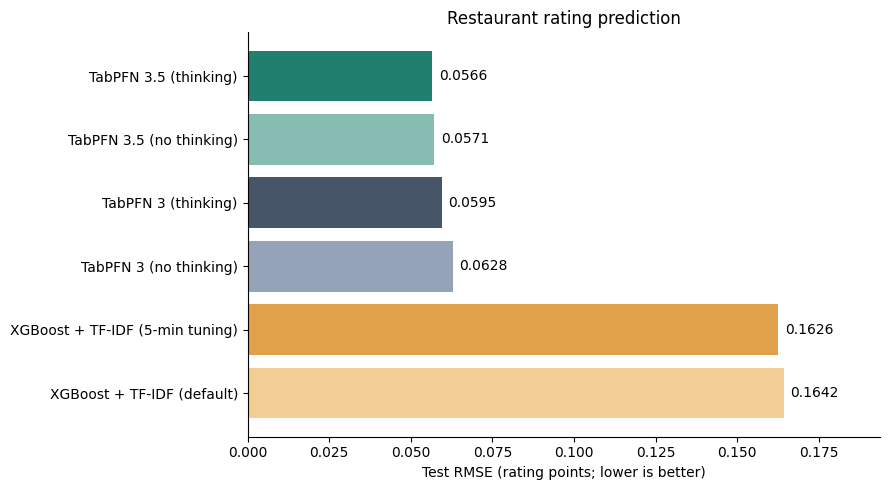

In [11]:
model_order = [
    "TabPFN 3 (no thinking)", "TabPFN 3 (thinking)",
    "TabPFN 3.5 (no thinking)", "TabPFN 3.5 (thinking)",
    "XGBoost + TF-IDF (default)", "XGBoost + TF-IDF (5-min tuning)",
]
scores = (pd.DataFrame(results).set_index("Model").reindex(model_order)
          .sort_values("RMSE ↓", kind="stable"))
display(scores.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
colors = dict(zip(model_order, ["#94a3b8", "#475569", "#86bcb1", "#21806d", "#f3ce94", "#e0a14a"]))
bars = ax.barh(scores.index, scores["RMSE ↓"], color=[colors[name] for name in scores.index])
assert np.isfinite(scores.to_numpy()).all(), "Every model must have measured scores."
ax.bar_label(bars, labels=[f"{value:.4f}" for value in scores["RMSE ↓"]], padding=5)
ax.set_xlabel("Test RMSE (rating points; lower is better)")
ax.set_title("Restaurant rating prediction")
ax.set_xlim(0, scores["RMSE ↓"].max() * 1.18)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


TabPFN 3.5 reduces test RMSE from 0.0628 to 0.0571 rating points compared with TabPFN 3 in standard mode. Thinking improves RMSE for both versions: to 0.0595 for TabPFN 3 and 0.0566 for TabPFN 3.5. Tuned XGBoost reaches 0.1626. These scores describe this listing-level task, where restaurants can recur and reviews contain individual rating scores.
